# GISPR Module 1 — Why Python and R for Spatial Data Science

**Course:** GIS Spatial Analysis with Python and R (GISPR)  
**Module:** 1 — Getting Started  
**Session:** Autumn 2026 · UW Professional & Continuing Education

---

## What this module covers

Module 1 is about building the foundation you need to write spatial analysis code — and understanding *why* that matters for your work as a GIS professional.

| Topic | What you'll learn | Where |
|---|---|---|
| The motivating problem | A hypothetical scenario | Section 1 |
| Variables and data types | How programs store and classify values | Section 2 |
| Strings | Text manipulation for field names, file paths, labels | Section 3 |
| Lists and vectors | Ordered collections of observations or coordinates | Section 4 |
| Dictionaries / named lists | Key-value stores for feature attributes | Section 5 |
| Data frames | The tabular backbone of spatial attribute tables | Section 6 |
| Writing functions | Package reusable logic; build reproducible workflows | Section 7 |
| Packages and imports | How R and Python extend their base capabilities | Section 8 |
| Your first geometry | Create a spatial feature with geometry + attributes + CRS | Section 9 |
| Documenting with Markdown | Write analysis that can be shared and re-run | Section 10 |

## Learning outcomes

By the end of this notebook you will be able to:

1. Explain why scripting extends — not replaces — your existing ArcGIS workflows
2. Identify core data types and use them in both R and Python
3. Write a basic function and call it on real data
4. Load the spatial packages needed for the rest of the course
5. Create a simple spatial feature (point with attributes and CRS) in both languages
6. Document your work in a Jupyter notebook using Markdown

## How this notebook is structured

**In-class (Sections 1–4):** We work through the motivating problem and the core concepts together. Run cells as we go — modify, break things, fix them.

**On your own (Sections 5–10 + Homework):** Complete the remaining sections after the session. This completed notebook *is* your homework deliverable.

### Kernel guide
- 🔵 **`[R]`** cells — switch kernel to **R** before running
- 🟢 **`[Python]`** cells — switch kernel to **Python 3** (or your ArcGIS Pro conda env) before running

> **Goal:** Not memorizing syntax. Building the habit of: *define the problem → write code → inspect output → document → reuse.*

---
## Section 1 — The Motivating Problem

Before we look at any syntax, here's the kind of problem that makes Python and R worth learning.

---

**Scenario:** Every quarter, your team receives updated field observation data from 12 monitoring stations across Puget Sound. Your job: produce a summary report — average precipitation by station, flag stations above threshold, convert units — and deliver it as a formatted table.

**Manual workflow in ArcGIS/Excel:** Open the file. Sort by station name. Filter by date range. Calculate a new field. Copy to Excel. Format the table. Paste into the report. Repeat next quarter.

**With Python or R:** Write it once. Run it every quarter in seconds. Share the script with your team. Document every decision inside the code.

---

The cells below show what that payoff looks like. **Don't worry about understanding every line yet** — that's what the rest of this notebook is for. Just run the cells and look at the output.

🔵 **`R`**

In [1]:
# [R] The payoff — a complete station summary in ~15 lines
# Run this with an R kernel. We'll explain every part of this later.

stations <- data.frame(
  name          = c("Sea-Tac", "Olympia", "Bellingham", "Spokane", "Wenatchee"),
  lat           = c(47.44,     47.00,      48.79,        47.62,     47.42),
  lon           = c(-122.31,  -122.90,    -122.54,      -117.53,   -120.31),
  elev_m        = c(133,       61,         45,            720,       378),
  ann_precip_cm = c(96,        124,         95,            43,        28)
)

# Convert units, classify, and flag — all at once
stations$elev_ft  <- round(stations$elev_m * 3.28084, 1)
stations$wet_flag <- stations$ann_precip_cm > 90

# Summary
cat("Mean precipitation (cm):", mean(stations$ann_precip_cm), "\n")
cat("Stations above 90 cm:\n")
print(stations[stations$wet_flag, c("name", "ann_precip_cm")])

Mean precipitation (cm): 77.2 
Stations above 90 cm:
        name ann_precip_cm
1    Sea-Tac            96
2    Olympia           124
3 Bellingham            95


In [2]:
head(stations)

,name,lat,lon,elev_m,ann_precip_cm,elev_ft,wet_flag
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>
1,Sea-Tac,47.44,-122.31,133,96,436.4,TRUE
2,Olympia,47.00,-122.90,61,124,200.1,TRUE
3,Bellingham,48.79,-122.54,45,95,147.6,TRUE
4,Spokane,47.62,-117.53,720,43,2362.2,FALSE
5,Wenatchee,47.42,-120.31,378,28,1240.2,FALSE


🟢 **Python**

In [1]:
# [Python] The same result — same logic, different syntax
# Run this with a Python kernel.

import pandas as pd

stations = pd.DataFrame({
    "name":          ["Sea-Tac", "Olympia", "Bellingham", "Spokane", "Wenatchee"],
    "lat":           [47.44,     47.00,      48.79,        47.62,     47.42],
    "lon":           [-122.31,  -122.90,    -122.54,      -117.53,   -120.31],
    "elev_m":        [133,       61,         45,            720,       378],
    "ann_precip_cm": [96,        124,         95,            43,        28]
})

# Convert units, classify, and flag
stations["elev_ft"]  = (stations["elev_m"] * 3.28084).round(1)
stations["wet_flag"] = stations["ann_precip_cm"] > 90

# Summary
print(f"Mean precipitation (cm): {stations['ann_precip_cm'].mean():.1f}")
print("\nStations above 90 cm:")
print(stations.loc[stations["wet_flag"], ["name", "ann_precip_cm"]])

Mean precipitation (cm): 77.2

Stations above 90 cm:
         name  ann_precip_cm
0     Sea-Tac             96
1     Olympia            124
2  Bellingham             95


> **What you just ran** uses variables, data frames, computed columns, boolean filtering, and print functions — exactly the concepts in Sections 1–5 below. By the end of this notebook, you'll be able to read, modify, and write code like this yourself.

---

---
## Section 2 — Variables and Data Types

Both R and Python are **dynamically typed** — you don't declare a type, the language infers it from the value you assign.

| Concept | R | Python |
|---|---|---|
| Assignment | `x <- 42` | `x = 42` |
| Check type | `class(x)` | `type(x)` |
| Whole number | numeric | int |
| Decimal number | numeric (double) | float |
| Text | character | str |
| True/False | logical | bool |

> **Key difference:** R's conventional assignment operator is `<-` (though `=` also works). Python uses only `=`.

In the motivating problem above, `elev_m` held integers, `lat`/`lon` held floats, `name` held strings, and `wet_flag` held booleans. Data types determine what operations are legal on a value.

🔵 **`R`**

In [5]:
# [R] Variables and data types
# Run this cell with an R kernel

x    <- 42         # numeric (integer-like)
y    <- 3.14        # numeric (double)
name <- "GISPR"    # character string
flag <- TRUE        # logical (TRUE / FALSE)

# Inspect types
class(x)            # "numeric"
class(name)         # "character"
typeof(y)           # "double"
is.numeric(x)       # TRUE

# Print with labels
cat("x is:", x, "\n")
cat("type of x:", class(x), "\n")
cat("name:", name, "\n")

[1] "numeric"

[1] "character"

[1] "double"

[1] TRUE

x is: 42 
type of x: numeric 
name: GISPR 


🟢 **Python**

In [4]:
# [Python] Variables and data types
# Run this cell with a Python kernel

x    = 42.0           # int
y    = 3.14         # float
name = "GISPR"     # str
flag = True         # bool (capital T, not TRUE)

# Inspect types
print(type(x))              # <class 'int'>
print(type(name))           # <class 'str'>
print(isinstance(y, float)) # True

# Print with labels (f-string = modern Python)
print(f"x is: {x}")
print(f"type of x: {type(x).__name__}")
print(f"name: {name}")

<class 'float'>
<class 'str'>
True
x is: 42.0
type of x: float
name: GISPR


### 🔧 Try it yourself — Variables
- Change `x <- 42` to `x <- 42L` in R. Does the type change?
- Change `x = 42` to `x = 42.0` in Python. Does the type change?
- Create a new variable `city` assigned to the name of a city you've done GIS work in. Print it.

---
## Section 3 — Strings

String manipulation is essential for working with place names, file paths, field names, and data labels in GIS workflows.

| Task | R | Python |
|---|---|---|
| Length | `nchar(s)` | `len(s)` |
| Uppercase | `toupper(s)` | `s.upper()` |
| Substring | `substr(s, 1, 5)` | `s[:5]` |
| Split | `strsplit(s, ",")` | `s.split(",")` |
| Combine | `paste(a, b)` / `paste0(a, b)` | `f"{a}{b}"` |
| Contains? | `grepl("WA", s)` | `"WA" in s` |

🔵 **`R`**

In [ ]:
# [R] String operations

city <- "Seattle, WA"

nchar(city)             # 11
toupper(city)           # "SEATTLE, WA"
tolower(city)           # "seattle, wa"
substr(city, 1, 7)      # "Seattle"

# Split on ", "
parts <- strsplit(city, ", ")[[1]]
parts                   # "Seattle" "WA"

# Combine strings
print(paste("City:", city))    # "City: Seattle, WA")
print(paste0("layer_", 2024))  # "layer_2024" (no space)

# Pattern matching
print(grepl("WA", city))       # TRUE
print(grepl("OR", city))       # FALSE

# Build a file path string
folder <- "C:/GIS/data"
filename <- "watersheds.shp"
full_path <- paste0(folder, "/", filename)
print(cat(full_path))

🟢 **Python**

In [5]:
# [Python] String operations

city = "Seattle, WA"

print(len(city))            # 11
print(city.upper())         # SEATTLE, WA
print(city.lower())         # seattle, wa
print(city[:7])             # Seattle  (slicing)

# Split on ", "
parts = city.split(", ")
print(parts)                # ['Seattle', 'WA']

# Combine strings (f-string)
print(f"City: {city}")
print(f"layer_{2024}")

# Pattern matching
print("WA" in city)         # True
print(city.startswith("Sea"))  # True
print(city.endswith("OR"))  # False

# Build a file path (use os.path in real projects)
import os
folder   = "C:/GIS/data"
filename = "watersheds.shp"
full_path = os.path.join(folder, filename)
print(full_path)

11
SEATTLE, WA
seattle, wa
Seattle
['Seattle', 'WA']
City: Seattle, WA
layer_2024
True
True
False
C:/GIS/data/watersheds.shp


### 🔧 Try it yourself — Strings
- Create a variable `field_name = "total population 2020"` and convert it to snake_case: `"total_population_2020"` using `.replace()` in Python or `gsub()` in R.
- Build the string `"GISPR_Module1_data.csv"` from three separate variables.

🟢 **Python**

In [7]:
field_name = "total population 2020"
field_name = field_name.replace(' ','_')
print(field_name)

total_population_2020


In [1]:
# Define the three separate variables
part1 = "GISPR"
part2 = "Module1"
part3 = "data.csv"

# Method 1: Using f-strings (Formatted String Literals)
# This is the most modern, readable, and preferred way in Python.
result_fstring = f"{part1}_{part2}_{part3}"
print(result_fstring)  # Output: GISPR_Module1_data.csv

# Method 2: Using the join() method
# This is highly efficient and clean when combining items with a common separator.
result_join = "_".join([part1, part2, part3])
print(result_join)     # Output: GISPR_Module1_data.csv

# Method 3: just use the + operator
result_join = part1 + "_" + part2 + "_" + part3
print(result_join)

GISPR_Module1_data.csv
GISPR_Module1_data.csv
GISPR_Module1_data.csv


🔵 **`R`**

In [1]:
field_name = "total population 2020"
field_name = gsub(" ", "_", field_name)
print(field_name)

[1] "total_population_2020"


In [3]:
# Define the three separate variables
part1 <- "GISPR"
part2 <- "Module1"
part3 <- "data.csv"

# Method 1: Using the base paste() function
# The collapse/separator logic is handled directly by the 'sep' argument.
result_paste <- paste(part1, part2, part3, sep = "_")
print(result_paste)  # Output: GISPR_Module1_data.csv

# Method 2: Using the glue package (similar to Python f-strings)
# This provides clean, readable literal interpolation.
# (Requires install.packages("glue") if not already installed)
result_glue <- glue::glue("{part1}_{part2}_{part3}")
print(result_glue)  # Output: GISPR_Module1_data.csv

GISPR_Module1_data.csv


---
## Section 4 — Lists and Vectors

Ordered collections of values — the foundation for storing multiple observations, coordinates, or field values.

> ⚠️ **The most common gotcha switching between R and Python:**
> - **R** uses **1-based indexing** — first element is `[1]`
> - **Python** uses **0-based indexing** — first element is `[0]`

R's vectors require all elements to be the same type. Python lists can mix types.

🔵 **`R`**

In [ ]:
# [R] Vectors

# Create a numeric vector
elevations <- c(0, 145, 890, 4392)   # c() = "combine"

length(elevations)      # 4
elevations[1]           # 0   <- FIRST element is index 1
elevations[2:4]         # 145, 890, 4392
elevations[length(elevations)]  # last element: 4392

# Add an element
elevations <- c(elevations, 500)
elevations              # 0 145 890 4392 500

# Vectorized math (applies to every element at once)
elevations_ft <- elevations * 3.28084
elevations_ft

# Summary stats
mean(elevations)
max(elevations)
sum(elevations)

# Character vector
states <- c("WA", "OR", "CA", "ID")
states[states == "WA"]              # filter: "WA"
states[nchar(states) == 2]          # all 2-char: all of them

# Named vector (like a simple lookup)
pop <- c(Seattle = 737000, Portland = 652000, Boise = 241000)
pop["Seattle"]

🟢 **Python**

In [1]:
# [Python] Lists

# Create a list
elevations = [0, 145, 890, 4392]

print(len(elevations))          # 4
print(elevations[0])            # 0   <- FIRST element is index 0
print(elevations[1:4])          # [145, 890, 4392]  (end index exclusive)
print(elevations[-1])           # last element: 4392

# Add an element
elevations.append(500)
print(elevations)               # [0, 145, 890, 4392, 500]

# List comprehension (compact loop)
elevations_ft = [e * 3.28084 for e in elevations]
print(elevations_ft)

# Summary stats (import statistics or use numpy)
import statistics
print(statistics.mean(elevations))
print(max(elevations))
print(sum(elevations))

# Filter with comprehension
states = ["WA", "OR", "CA", "ID"]
wa_only = [s for s in states if s == "WA"]
print(wa_only)                  # ['WA']

# Python lists can mix types (R vectors cannot)
mixed = ["Seattle", 737000, True, 47.6062]
print(mixed)

4
0
[145, 890, 4392]
4392
[0, 145, 890, 4392, 500]
[0.0, 475.7218, 2919.9476, 14409.44928, 1640.42]
1185.4
4392
5927
['WA']
['Seattle', 737000, True, 47.6062]


### 🔧 Try it yourself — Lists / Vectors
- Create a vector/list of 5 latitude values for cities you know.
- Compute the average latitude.
- Filter to only latitudes above 45 degrees.
- In Python: convert your list to a numpy array and multiply to see vectorized behavior like R.

🟢 **Python**

In [2]:
import numpy as np

# 1. Create a list of 5 latitude values for cities I know
# Corvallis, Bend, San Francisco, Denver, Missoula
latitudes = [44.5646, 44.0582, 37.7749, 39.7392, 46.8721]

# 2. Compute the average latitude
average_lat = sum(latitudes) / len(latitudes)
print(f"Average latitude: {average_lat:.4f}")

# 3. Filter to only latitudes above 45 degrees
filtered_lats = [lat for lat in latitudes if lat > 45]
print(f"Latitudes above 45 degrees: {filtered_lats}")

# 4. Convert the original list to a numpy array and multiply (e.g., by 2)
lat_array = np.array(latitudes)
multiplied_array = lat_array * 2
print(f"Numpy array multiplied by 2:\n{multiplied_array}")

Average latitude: 42.6018
Latitudes above 45 degrees: [46.8721]
Numpy array multiplied by 2:
[89.1292 88.1164 75.5498 79.4784 93.7442]


🔵 **`R`**

In [1]:
# 1. Create a vector of latitude values for the specified cities
# Corvallis (OR), Bend (OR), San Francisco (CA), Denver (CO), Missoula (MT)
latitudes <- c(44.5646, 44.0582, 37.7749, 39.7392, 46.8721)

# 2. Compute the average latitude
average_lat <- mean(latitudes)
cat("Average latitude:", round(average_lat, 4), "\n")

# 3. Filter to only latitudes above 45 degrees
filtered_lats <- latitudes[latitudes > 45]
cat("Latitudes above 45 degrees:", filtered_lats, "\n")

# 4. Multiply the vector (R vectors support native vectorization like NumPy arrays)
multiplied_vector <- latitudes * 2
cat("Vector multiplied by 2:\n", multiplied_vector, "\n")

Average latitude: 42.6018 
Latitudes above 45 degrees: 46.8721 
Vector multiplied by 2:
 89.1292 88.1164 75.5498 79.4784 93.7442 


---
## ⏸ End of In-Class Portion

Sections 1–4 are what we work through together during the live session. If you're ahead, start Section 5 now — otherwise, continue on your own after class.

**Sections 5–10 are your homework.** Complete them and submit this notebook with all cells run and output visible. See the homework instructions at the bottom of this notebook.

---

---
## Section 5 — Dictionaries / Named Lists

Key-value stores — essential for representing a single GIS feature's attributes, config settings, or lookup tables.

| Task | R (named list) | Python (dict) |
|---|---|---|
| Create | `list(key = val)` | `{"key": val}` |
| Access by name | `d$key` or `d[["key"]]` | `d["key"]` or `d.get("key")` |
| Add/update | `d$new <- val` | `d["new"] = val` |
| All keys | `names(d)` | `d.keys()` |
| Iterate | `for (k in names(d))` | `for k, v in d.items()` |

🔵 **`R`**

In [2]:
# [R] Named lists as dictionaries

# A single GIS feature represented as a named list
feature <- list(
  name    = "Green Lake",
  type    = "lake",
  area_ha = 105.2,
  city    = "Seattle",
  lat     = 47.6796,
  lon     = -122.3378
)

# Access by name (two ways)
feature$name              # "Green Lake"
feature[["area_ha"]]      # 105.2

# Add a new field
feature$source <- "City of Seattle Open Data"

# See all keys
names(feature)

# Iterate and print all fields
for (key in names(feature)) {
  cat(key, ":", as.character(feature[[key]]), "\n")
}

# Check if a key exists
"city" %in% names(feature)    # TRUE
"county" %in% names(feature)  # FALSE

[1] "Green Lake"

[1] 105.2

[1] "name"    "type"    "area_ha" "city"    "lat"     "lon"     "source"

name : Green Lake 
type : lake 
area_ha : 105.2 
city : Seattle 
lat : 47.6796 
lon : -122.3378 
source : City of Seattle Open Data 


[1] TRUE

[1] FALSE

🟢 **Python**

In [1]:
# [Python] Dictionaries

# A single GIS feature as a dict
feature = {
    "name":    "Green Lake",
    "type":    "lake",
    "area_ha": 105.2,
    "city":    "Seattle",
    "lat":     47.6796,
    "lon":     -122.3378
}

# Access by key
print(feature["name"])           # Green Lake
print(feature.get("area_ha"))    # 105.2
print(feature.get("county", "unknown"))  # safe: returns default

# Add a new field
feature["source"] = "City of Seattle Open Data"

# See all keys
print(list(feature.keys()))

# Iterate and print all fields
for key, val in feature.items():
    print(f"{key}: {val}")

# Check if a key exists
print("city" in feature)        # True
print("county" in feature)      # False

Green Lake
105.2
unknown
['name', 'type', 'area_ha', 'city', 'lat', 'lon', 'source']
name: Green Lake
type: lake
area_ha: 105.2
city: Seattle
lat: 47.6796
lon: -122.3378
source: City of Seattle Open Data
True
False


### 🔧 Try it yourself — Dictionaries
- Create a feature representing a place you know (a park, building, or neighborhood). Include at least 4 fields.
- Add a `"notes"` field after creation.
- Write a loop that prints only fields where the value is a number.

🟢 **Python**

In [2]:
# 1. A feature for a place, with more than 4 fields
avery_park = {
    "name": "Avery Park",
    "city": "Corvallis",
    "type": "park",
    "area_acres": 75,
    "latitude": 44.5531,
    "longitude": -123.2722,
    "has_river_access": True,
}

# 2. Add a "notes" field after creating it
avery_park["notes"] = "Along the Marys River; rose garden and old steam locomotive."

# 3. Print only the fields whose value is a number
for field, value in avery_park.items():
    if isinstance(value, (int, float)) and not isinstance(value, bool):
        print(f"{field}: {value}")

area_acres: 75
latitude: 44.5531
longitude: -123.2722


🔵 **`R`**

In [3]:
# 1. A feature for a place, with more than 4 fields
avery_park <- list(
  name             = "Avery Park",
  city             = "Corvallis",
  type             = "park",
  area_acres       = 75,
  latitude         = 44.5531,
  longitude        = -123.2722,
  has_river_access = TRUE
)

# 2. Add a "notes" field after creating it
avery_park$notes <- "Along the Marys River; rose garden and old steam locomotive."

# 3. Print only the fields whose value is a number
for (field in names(avery_park)) {
  value <- avery_park[[field]]
  if (is.numeric(value)) {
    cat(field, ":", value, "\n")
  }
}

area_acres : 75 
latitude : 44.5531 
longitude : -123.2722 


---
## Section 6 — Data Frames

Tabular data with named columns — the central data structure for GIS attribute tables. Think of it as a spreadsheet in code.

This is the structure we used in Section 1's motivating problem. Now you understand why: a data frame holds the same kind of information as a feature class attribute table, with each row a feature and each column a field.

| Task | R | Python (pandas) |
|---|---|---|
| Create | `data.frame(...)` | `pd.DataFrame({...})` |
| Row count | `nrow(df)` | `len(df)` |
| Column names | `names(df)` | `df.columns` |
| Access column | `df$col` | `df["col"]` |
| Filter rows | `df[df$col > 100, ]` | `df[df["col"] > 100]` |
| Add column | `df$new <- values` | `df["new"] = values` |
| Summary | `summary(df)` | `df.describe()` |

🔵 **`R`**

In [8]:
# [R] Data frames — weather stations

stations <- data.frame(
  name    = c("Sea-Tac", "Olympia", "Bellingham", "Spokane"),
  lat     = c(47.44,     47.00,      48.79,        47.62),
  lon     = c(-122.31,  -122.90,    -122.54,      -117.53),
  elev_m  = c(133,       61,         45,            720),
  ann_precip_cm = c(96,  124,         95,            43)
)

# Inspect the data frame
nrow(stations)           # 4
ncol(stations)           # 5
names(stations)          # column names
str(stations)            # structure + types
head(stations, 2)        # first 2 rows
summary(stations)        # quick stats

# Access a column
stations$lat
stations[["name"]]

# Access a single value (row 2, elev_m)
stations[2, "elev_m"]    # 61

# Filter rows
wet <- stations[stations$ann_precip_cm > 90, ]
wet

# Add a computed column
stations$elev_ft <- round(stations$elev_m * 3.28084, 1)
stations

[1] 4

[1] 5

[1] "name"          "lat"           "lon"           "elev_m"       
[5] "ann_precip_cm"

'data.frame':	4 obs. of  5 variables:
 $ name         : chr  "Sea-Tac" "Olympia" "Bellingham" "Spokane"
 $ lat          : num  47.4 47 48.8 47.6
 $ lon          : num  -122 -123 -123 -118
 $ elev_m       : num  133 61 45 720
 $ ann_precip_cm: num  96 124 95 43


,name,lat,lon,elev_m,ann_precip_cm
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
1,Sea-Tac,47.44,-122.31,133,96
2,Olympia,47.00,-122.90,61,124


...

[1] 47.44 47.00 48.79 47.62

[1] "Sea-Tac"    "Olympia"    "Bellingham" "Spokane"

[1] 61

,name,lat,lon,elev_m,ann_precip_cm
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
1,Sea-Tac,47.44,-122.31,133,96
2,Olympia,47.00,-122.90,61,124
3,Bellingham,48.79,-122.54,45,95


name,lat,lon,elev_m,ann_precip_cm,elev_ft
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Sea-Tac,47.44,-122.31,133,96,436.4
Olympia,47.00,-122.90,61,124,200.1
Bellingham,48.79,-122.54,45,95,147.6
Spokane,47.62,-117.53,720,43,2362.2


🟢 **Python**

In [6]:
# [Python] pandas DataFrames — same weather stations

import pandas as pd

stations = pd.DataFrame({
    "name":          ["Sea-Tac", "Olympia", "Bellingham", "Spokane"],
    "lat":           [47.44,     47.00,      48.79,        47.62],
    "lon":           [-122.31,  -122.90,    -122.54,      -117.53],
    "elev_m":        [133,       61,         45,            720],
    "ann_precip_cm": [96,        124,         95,            43]
})

# Inspect the DataFrame
print(len(stations))         # 4 rows
print(stations.shape)        # (4, 5)
print(stations.columns.tolist())
print(stations.dtypes)
print(stations.head(2))
print(stations.describe())

# Access a column
print(stations["lat"])
print(stations.name)         # dot notation also works

# Access a single value (row 1, elev_m)
print(stations.loc[1, "elev_m"])   # 61

# Filter rows
wet = stations[stations["ann_precip_cm"] > 90]
print(wet)

# Add a computed column
stations["elev_ft"] = (stations["elev_m"] * 3.28084).round(1)
print(stations)

4
(4, 5)
['name', 'lat', 'lon', 'elev_m', 'ann_precip_cm']
name                 str
lat              float64
lon              float64
elev_m             int64
ann_precip_cm      int64
dtype: object
      name    lat     lon  elev_m  ann_precip_cm
0  Sea-Tac  47.44 -122.31     133             96
1  Olympia  47.00 -122.90      61            124
             lat         lon      elev_m  ann_precip_cm
count   4.000000    4.000000    4.000000       4.000000
mean   47.712500 -121.320000  239.750000      89.500000
std     0.764084    2.538307  322.446249      33.788558
min    47.000000 -122.900000   45.000000      43.000000
25%    47.330000 -122.630000   57.000000      82.000000
50%    47.530000 -122.425000   97.000000      95.500000
75%    47.912500 -121.115000  279.750000     103.000000
max    48.790000 -117.530000  720.000000     124.000000
0    47.44
1    47.00
2    48.79
3    47.62
Name: lat, dtype: float64
0       Sea-Tac
1       Olympia
2    Bellingham
3       Spokane
Name: name, dtype

### 🔧 Try it yourself — Data Frames
- Add a 5th station of your choice.
- Filter to stations west of -120 longitude (west side of the Cascades).
- Compute a new column `precip_per_meter_elevation` = `ann_precip_cm / elev_m`. Which station has the highest ratio?

🟢 **Python**

In [7]:
# 1. Add a 5th station (Corvallis, OR)
new_station = pd.DataFrame({
    "name":          ["Corvallis"],
    "lat":           [44.57],
    "lon":           [-123.26],
    "elev_m":        [70],
    "ann_precip_cm": [110],
})
new_station["elev_ft"] = (new_station["elev_m"] * 3.28084).round(1)

stations = pd.concat([stations, new_station], ignore_index=True)  # we use pd.concat to add our new Corvallis data frame to the one above
print(stations)

# 2. Filter to stations west of -120 longitude (west of the Cascades)
west = stations[stations["lon"] < -120].copy()
print(west)

# 3. Precipitation per meter of elevation
west["precip_per_meter_elevation"] = (west["ann_precip_cm"] / west["elev_m"]).round(2)
print(west[["name", "elev_m", "ann_precip_cm", "precip_per_meter_elevation"]])

         name    lat     lon  elev_m  ann_precip_cm  elev_ft
0     Sea-Tac  47.44 -122.31     133             96    436.4
1     Olympia  47.00 -122.90      61            124    200.1
2  Bellingham  48.79 -122.54      45             95    147.6
3     Spokane  47.62 -117.53     720             43   2362.2
4   Corvallis  44.57 -123.26      70            110    229.7
         name    lat     lon  elev_m  ann_precip_cm  elev_ft
0     Sea-Tac  47.44 -122.31     133             96    436.4
1     Olympia  47.00 -122.90      61            124    200.1
2  Bellingham  48.79 -122.54      45             95    147.6
4   Corvallis  44.57 -123.26      70            110    229.7
         name  elev_m  ann_precip_cm  precip_per_meter_elevation
0     Sea-Tac     133             96                        0.72
1     Olympia      61            124                        2.03
2  Bellingham      45             95                        2.11
4   Corvallis      70            110                        1.57


🔵 **`R`**

In [9]:
# 1. Add a 5th station (Corvallis, OR)
new_station <- data.frame(
  name          = "Corvallis",
  lat           = 44.57,
  lon           = -123.26,
  elev_m        = 70,
  ann_precip_cm = 110
)
new_station$elev_ft <- round(new_station$elev_m * 3.28084, 1)

stations <- rbind(stations, new_station)  # rbind is the R equivalent of pd.concat that we used above for Python pandas dataframes
stations

# 2. Filter to stations west of -120 longitude (west of the Cascades)
west <- stations[stations$lon < -120, ]
west

# 3. Precipitation per meter of elevation
west$precip_per_meter_elevation <- round(west$ann_precip_cm / west$elev_m, 2)
west[, c("name", "elev_m", "ann_precip_cm", "precip_per_meter_elevation")]

# And as a bonus, here is the 'tidyverse' version of both steps 2 and 3 above using the 'chained' syntax I mentioned last week
# I find this much more intuitive
library(dplyr)
options(warn = -1)  #  you may wonder what this is - this suppresses warning messages from output - some libraries will give warnings about their behavior for a user to see
west <- stations |> filter(lon < -120) |> mutate(precip_per_meter_elevation = round(ann_precip_cm / elev_m, 2))

name,lat,lon,elev_m,ann_precip_cm,elev_ft
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Sea-Tac,47.44,-122.31,133,96,436.4
Olympia,47.00,-122.90,61,124,200.1
Bellingham,48.79,-122.54,45,95,147.6
Spokane,47.62,-117.53,720,43,2362.2
Corvallis,44.57,-123.26,70,110,229.7


,name,lat,lon,elev_m,ann_precip_cm,elev_ft
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,Sea-Tac,47.44,-122.31,133,96,436.4
2,Olympia,47.00,-122.90,61,124,200.1
3,Bellingham,48.79,-122.54,45,95,147.6
5,Corvallis,44.57,-123.26,70,110,229.7


,name,elev_m,ann_precip_cm,precip_per_meter_elevation
,<chr>,<dbl>,<dbl>,<dbl>
1,Sea-Tac,133,96,0.72
2,Olympia,61,124,2.03
3,Bellingham,45,95,2.11
5,Corvallis,70,110,1.57


---
## Section 7 — Writing Functions

Functions let you package reusable logic — critical for building reproducible GIS workflows. You define once, call many times.

Both languages support:
- **Default arguments** — parameters with fallback values
- **Returning values** — `return()` in R, `return` in Python
- **Vectorization** — R functions often work on whole vectors automatically; Python needs explicit loops or libraries like numpy

> ⚠️ **Differences between functions in R and Python:**
> - **R** attaches the function to an object: `func_name <- function(parameter) { … }`
> - **Python** uses `def` with a colon and indentation: `def name_of_function(parameter):`

Both use `return` to specify what the function outputs.

🔵 **`R`**

In [10]:
# [R] Writing and using functions

# Basic function
meters_to_feet <- function(m) {
  m * 3.28084
}
meters_to_feet(100)       # 328.084
meters_to_feet(c(53, 61, 720))  # works on a whole vector!

# Function with default argument
summarize_col <- function(x, digits = 2, label = "") {
  result <- list(
    label = label,
    n     = length(x),
    mean  = round(mean(x), digits),
    min   = min(x),
    max   = max(x),
    range = max(x) - min(x)
  )
  return(result)
}

# Call with and without the optional args
summarize_col(c(133, 61, 45, 720))
summarize_col(c(133, 61, 45, 720), digits = 0, label = "Elevation (m)")

# Function that checks a condition
classify_precip <- function(precip_cm) {
  if (precip_cm > 100) {
    return("wet")
  } else if (precip_cm > 50) {
    return("moderate")
  } else {
    return("dry")
  }
}

classify_precip(96)    # "moderate" — check the threshold!
classify_precip(43)    # "dry"

# Apply over a vector using sapply
precips <- c(96, 124, 95, 43)
sapply(precips, classify_precip)

[1] 328.084

[1]  173.8845  200.1312 2362.2048

$label
[1] ""

$n
[1] 4

$mean
[1] 239.75

$min
[1] 45

$max
[1] 720

$range
[1] 675

$label
[1] "Elevation (m)"

$n
[1] 4

$mean
[1] 240

$min
[1] 45

$max
[1] 720

$range
[1] 675

[1] "moderate"

[1] "dry"

[1] "moderate" "wet"      "moderate" "dry"

🟢 **Python**

In [3]:
# [Python] Writing and using functions

# Basic function
def meters_to_feet(m):
    return m * 3.28084

print(meters_to_feet(100))       # 328.084
# Doesn't auto-vectorize — need a loop or numpy
print([meters_to_feet(e) for e in [53, 61, 720]])

# Function with default arguments
import statistics

def summarize_col(x, digits=2, label=""):
    return {
        "label": label,
        "n":     len(x),
        "mean":  round(statistics.mean(x), digits),
        "min":   min(x),
        "max":   max(x),
        "range": max(x) - min(x)
    }

# Call with and without optional args
print(summarize_col([133, 61, 45, 720]))
print(summarize_col([133, 61, 45, 720], digits=0, label="Elevation (m)"))

# Function with conditional logic
def classify_precip(precip_cm):
    if precip_cm > 100:
        return "wet"
    elif precip_cm > 50:
        return "moderate"
    else:
        return "dry"

print(classify_precip(96))       # "moderate" — note the threshold!
print(classify_precip(43))       # "dry"

# Apply over a list
precips = [96, 124, 95, 43]
print([classify_precip(p) for p in precips])

# Lambda: one-liner function
to_feet = lambda m: round(m * 3.28084, 1)
print(to_feet(720))

328.084
[173.88452, 200.13124, 2362.2048]
{'label': '', 'n': 4, 'mean': 239.75, 'min': 45, 'max': 720, 'range': 675}
{'label': 'Elevation (m)', 'n': 4, 'mean': 240.0, 'min': 45, 'max': 720, 'range': 675}
moderate
dry
['moderate', 'wet', 'moderate', 'dry']
2362.2


# 🔧 Try it yourself — Functions
- Write a function `dd_to_dms(decimal_degrees)` that converts a decimal degree coordinate (like `47.6205`) to degrees, minutes, seconds format.
- Add a second argument `direction` with a default of `"N"` and include it in the output string.
- **Extension:** Wrap the Section 1 payoff code in a function called `station_summary(df, threshold)` that takes any station data frame and a precipitation threshold, and returns the flagged rows.

🔵 **`R`**

In [15]:
dd_to_dms <- function(decimal_degrees, direction = "N") {
  # Work in whole seconds (to 0.1) so rounding can't produce 60 seconds
  total_sec <- round(abs(decimal_degrees) * 3600, 1) 
  degrees   <- total_sec %/% 3600  # % here is the R modulo operator - it returns the remainder after divison here
  minutes   <- (total_sec %% 3600) %/% 60
  seconds   <- total_sec %% 60

  sprintf("%d\u00B0%02d'%04.1f\" %s",
          as.integer(degrees), as.integer(minutes), seconds, direction)  # here % is different than above - it is a placeholder for the variables that follow
                                                                         # and sprintf in R returns a formatted string
}

dd_to_dms(47.6205)                  # "47°37'13.8\" N"
dd_to_dms(122.3493, "W")            # "122°20'57.5\" W"
dd_to_dms(c(47.44, 47.00, 48.79))   # works on a whole column too
dd_to_dms(47.999999)                # "48°00'00.0\" N", not 47°59'60.0"

[1] "47°37'13.8\" N"

[1] "122°20'57.5\" W"

[1] "47°26'24.0\" N" "47°00'00.0\" N" "48°47'24.0\" N"

[1] "48°00'00.0\" N"

In [14]:
station_summary <- function(df, threshold) {
  df$wet_flag <- df$ann_precip_cm > threshold

  cat("Mean precipitation (cm):", mean(df$ann_precip_cm), "\n")
  cat("Stations above", threshold, "cm:\n")

  flagged <- df[df$wet_flag, c("name", "ann_precip_cm")]
  print(flagged)
  invisible(flagged)
}

wet <- station_summary(stations, 90)

Mean precipitation (cm): 93.6 
Stations above 90 cm:
        name ann_precip_cm
1    Sea-Tac            96
2    Olympia           124
3 Bellingham            95
5  Corvallis           110


🟢 **Python**

In [1]:
def dd_to_dms(decimal_degrees, direction="N"):
    # Work in whole tenths of a second, so all the math is on integers
    tenths = round(abs(decimal_degrees) * 36000)
    degrees, rem = divmod(tenths, 36000)        # 1° = 36000 tenths of a second
    minutes, sec_tenths = divmod(rem, 600)      # 1' = 600 tenths of a second
    return f"{degrees}\u00B0{minutes:02d}'{sec_tenths / 10:04.1f}\" {direction}"

dd_to_dms(47.6205)          # 47°37'13.8" N
dd_to_dms(122.3493, "W")    # 122°20'57.5" W
dd_to_dms(47.999999)        # 48°00'00.0" N

'48°00\'00.0" N'

In [8]:
import pandas as pd

def station_summary(df, threshold):
    df = df.copy()   # don't modify the caller's DataFrame
    df["elev_ft"]  = (df["elev_m"] * 3.28084).round(1)
    df["wet_flag"] = df["ann_precip_cm"] > threshold

    print("Mean precipitation (cm):", df["ann_precip_cm"].mean())
    print(f"Stations above {threshold} cm:")

    flagged = df.loc[df["wet_flag"], ["name", "ann_precip_cm"]]
    print(flagged)
    return flagged

wet = station_summary(stations, 90)

Mean precipitation (cm): 93.6
Stations above 90 cm:
         name  ann_precip_cm
0     Sea-Tac             96
1     Olympia            124
2  Bellingham             95
4   Corvallis            110


---
## Section 8 — Packages and Imports

Both languages extend their base capabilities through packages. The pattern:

1. **Install once** (in your terminal or R console — not in your script)
2. **Import/load at the top of every script or notebook**

### Spatial packages we'll use in this course

| Purpose | R | Python |
|---|---|---|
| Vector GIS | `sf` | `geopandas` |
| Raster | `terra` | `rasterio` |
| Geometry | `sf` (built-in) | `shapely` |
| Visualization | `ggplot2`, `tmap` | `matplotlib`, `folium` |
| ArcGIS integration | `arcgisbinding` | `arcpy`, `arcgis` |
| Data wrangling | `dplyr`, `tidyr` | `pandas`, `numpy` |

> **Note for ArcGIS Pro users:** Most Python spatial packages — including `arcpy` — are pre-installed in your ArcGIS Pro conda environment. You generally don't need to install them manually.
**
> **Note on installs:** for our Jupyter Notebook these libraries are already installed.  For working locally with RStudio and / or Positron or in a local Python environment you will need to run these steps.  We will dive into this more in coming modules

🔵 **`R`**

In [ ]:
# [R] Installing and loading packages

# --- INSTALL (run once in your R console, not here) ---
# install.packages("sf")
# install.packages("terra")
# install.packages("ggplot2")
# install.packages("dplyr")

# --- LOAD (run at the top of every script/notebook) ---
library(sf)
library(ggplot2)

# Alternatively, use :: to call without loading the whole package
# dplyr::filter(my_df, pop > 1000)

# Check what's installed
installed_pkgs <- rownames(installed.packages())
cat("sf installed:", "sf" %in% installed_pkgs, "\n")

# Check version of a loaded package
packageVersion("sf")

🟢 **Python**

In [9]:
# [Python] Installing and importing packages

# --- INSTALL (run once in your terminal, not here) ---
# pip install geopandas rasterio shapely matplotlib
# OR with conda: conda install -c conda-forge geopandas

# In ArcGIS Pro: most spatial packages are pre-installed!

# --- IMPORT (run at the top of every script/notebook) ---
import geopandas as gpd          # vector GIS
import pandas as pd              # data wrangling
import numpy as np               # numerical ops
import matplotlib.pyplot as plt  # plotting

# Import specific items from a package
from shapely.geometry import Point, Polygon

# Check what's available and their versions
print(f"geopandas: {gpd.__version__}")
print(f"pandas:    {pd.__version__}")
print(f"numpy:     {np.__version__}")

geopandas: 1.1.3
pandas:    3.0.3
numpy:     2.4.6


---
## Section 9 — Spatial Teaser: Your First Geometry

Everything in Sections 2–8 was building toward this. Here we create a real spatial feature — a point with coordinates — attach it to a data table, assign a coordinate reference system (CRS), and plot it.

This is the **core pattern** that scales to everything else in this course:
> **geometry + attributes + CRS = spatial feature**

Notice the connection to Section 0: the `stations` data frame becomes spatial the moment we assign coordinate columns as geometry and set a CRS.

> **Before running:** Make sure `sf` (R) or `geopandas` (Python) is installed (Section 7).

🔵 **`R`**

In [ ]:
# [R] First spatial feature with sf

library(sf)

# Step 1: define coordinates (longitude, latitude)
# Space Needle, Seattle
lon <- -122.3493
lat <-   47.6205

# Step 2: create a point geometry
pt <- st_point(c(lon, lat))
cat("Geometry type:", class(pt), "\n")

# Step 3: wrap in a geometry column with CRS
# EPSG 4326 = WGS 84 geographic (lat/lon degrees)
geom_col <- st_sfc(pt, crs = 4326)

# Step 4: build an sf data frame (geometry + attributes)
landmarks <- st_sf(
  name    = "Space Needle",
  year    = 1962,
  height_m = 184,
  geometry = geom_col
)

# Inspect
print(landmarks)
st_crs(landmarks)        # coordinate reference system
st_bbox(landmarks)       # bounding box

# Plot
plot(st_geometry(landmarks),
     pch = 16, col = "steelblue", cex = 2,
     main = "Space Needle — WGS 84",
     axes = TRUE)

🟢 **Python**

Geometry type: Point
Coordinates: [(-122.3493, 47.6205)]
           name  year  height_m                   geometry
0  Space Needle  1962       184  POINT (-122.3493 47.6205)
CRS: EPSG:4326
Total bounds: [-122.3493   47.6205 -122.3493   47.6205]


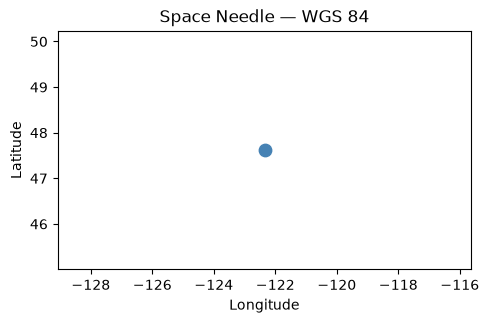

In [11]:
# [Python] First spatial feature with geopandas

import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point

# Step 1: define coordinates (longitude, latitude)
# Space Needle, Seattle
lon = -122.3493
lat =   47.6205

# Step 2: create a shapely Point geometry
pt = Point(lon, lat)
print(f"Geometry type: {pt.geom_type}")
print(f"Coordinates: {pt.coords[:]}")

# Steps 3 & 4: build a GeoDataFrame (geometry + attributes + CRS)
# EPSG 4326 = WGS 84 geographic (lat/lon degrees)
landmarks = gpd.GeoDataFrame(
    {
        "name":     ["Space Needle"],
        "year":     [1962],
        "height_m": [184]
    },
    geometry=[pt],
    crs="EPSG:4326"
)

# Inspect
print(landmarks)
print(f"CRS: {landmarks.crs}")
print(f"Total bounds: {landmarks.total_bounds}")

# Plot
fig, ax = plt.subplots(figsize=(5, 4))
landmarks.plot(ax=ax, marker='o', color='steelblue', markersize=80)
ax.set_title("Space Needle — WGS 84")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
plt.show()

### 🔧 Try it yourself — Spatial
- Add 2 more landmarks to the data (look up coordinates for nearby places).
- Plot all 3 points together and label them.
- In R: use `st_distance()` to compute distance between points.
- In Python: project to a UTM CRS (`"EPSG:32610"` for Seattle area) and use `.distance()` to compute distance in meters.
- **Extension:** Convert the `stations` data frame from Section 5 into a spatial data frame using its `lat`/`lon` columns. Plot the result.

🟢 **Python**

              name  year  height_m                   geometry
0     Space Needle  1962       184  POINT (-122.3493 47.6205)
1      Smith Tower  1914       149  POINT (-122.3317 47.6019)
2  Columbia Center  1985       284  POINT (-122.3305 47.6045)
0    POINT (548894.113 5274326.874)
1    POINT (550234.394 5272270.959)
2    POINT (550322.101 5272560.694)
Name: geometry, dtype: geometry
              name  dist_to_needle_m
0     Space Needle               0.0
1      Smith Tower            2454.0
2  Columbia Center            2271.0
name             Space Needle  Smith Tower  Columbia Center
name                                                       
Space Needle              0.0       2454.0           2271.0
Smith Tower            2454.0          0.0            303.0
Columbia Center        2271.0        303.0              0.0


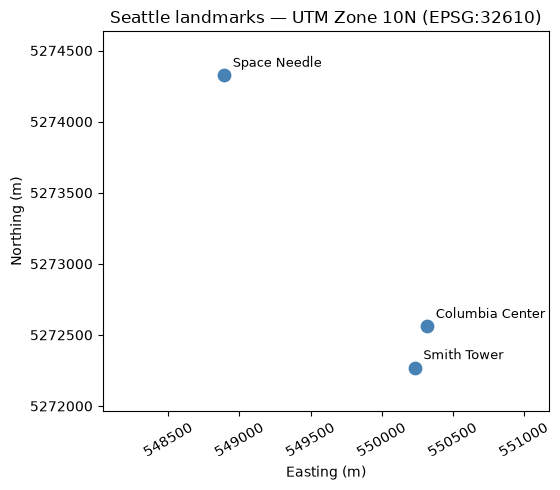

In [12]:
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point

# 1. Three landmarks (longitude, latitude)
landmarks = gpd.GeoDataFrame(
    {
        "name":     ["Space Needle", "Smith Tower", "Columbia Center"],
        "year":     [1962,           1914,          1985],
        "height_m": [184,            149,           284],
    },
    geometry=[
        Point(-122.3493, 47.6205),
        Point(-122.3317, 47.6019),
        Point(-122.3305, 47.6045),
    ],
    crs="EPSG:4326",
)
print(landmarks)

# 2. Project to UTM Zone 10N so the units are meters
landmarks_utm = landmarks.to_crs("EPSG:32610")
print(landmarks_utm.geometry)

# 3. Distance from each landmark to the Space Needle
needle = landmarks_utm.geometry.iloc[0]
landmarks_utm["dist_to_needle_m"] = landmarks_utm.distance(needle).round(0)
print(landmarks_utm[["name", "dist_to_needle_m"]])

# Bonus: distances between every pair of landmarks
dist_matrix = landmarks_utm.geometry.apply(lambda g: landmarks_utm.distance(g)).round(0)
dist_matrix.index = dist_matrix.columns = landmarks_utm["name"]
print(dist_matrix)

# 4. Plot and label all three points
fig, ax = plt.subplots(figsize=(6, 5))
landmarks_utm.plot(ax=ax, marker="o", color="steelblue", markersize=80)

for x, y, label in zip(landmarks_utm.geometry.x,
                       landmarks_utm.geometry.y,
                       landmarks_utm["name"]):
    ax.annotate(label, xy=(x, y), xytext=(6, 6),
                textcoords="offset points", fontsize=9)

ax.set_title("Seattle landmarks — UTM Zone 10N (EPSG:32610)")
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
ax.set_aspect("equal")
ax.margins(x=0.6, y=0.15)                              # room for labels
ax.ticklabel_format(style="plain", useOffset=False)    # no "1e6" offset
plt.setp(ax.get_xticklabels(), rotation=30)
plt.tight_layout()
plt.show()

         name    lat     lon  elev_m  ann_precip_cm               geometry
0     Sea-Tac  47.44 -122.31     133             96  POINT (-122.31 47.44)
1     Olympia  47.00 -122.90      61            124      POINT (-122.9 47)
2  Bellingham  48.79 -122.54      45             95  POINT (-122.54 48.79)
3     Spokane  47.62 -117.53     720             43  POINT (-117.53 47.62)


<Axes: >

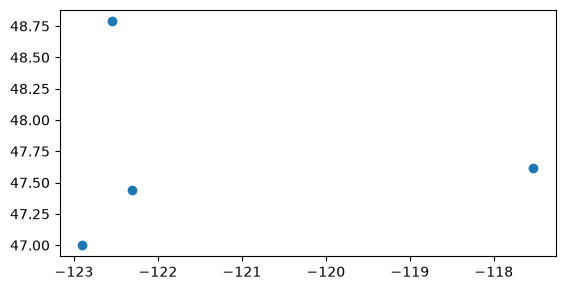

In [13]:
stations = pd.DataFrame({
    "name":          ["Sea-Tac", "Olympia", "Bellingham", "Spokane"],
    "lat":           [47.44,     47.00,      48.79,        47.62],
    "lon":           [-122.31,  -122.90,    -122.54,      -117.53],
    "elev_m":        [133,       61,         45,            720],
    "ann_precip_cm": [96,        124,         95,            43]
})

import geopandas as gpd

stations_gdf = gpd.GeoDataFrame(
    stations,
    geometry=gpd.points_from_xy(stations["lon"], stations["lat"]),
    crs="EPSG:4326",
)
print(stations_gdf)
stations_gdf.plot()

🔵 **`R`**

Simple feature collection with 3 features and 3 fields
Geometry type: POINT
Dimension:     XY
Bounding box:  xmin: -122.3493 ymin: 47.6019 xmax: -122.3305 ymax: 47.6205
Geodetic CRS:  WGS 84
             name year height_m                  geometry
1    Space Needle 1962      184 POINT (-122.3493 47.6205)
2     Smith Tower 1914      149 POINT (-122.3317 47.6019)
3 Columbia Center 1985      284 POINT (-122.3305 47.6045)


X,Y
548894.1,5274327
550234.4,5272271
550322.1,5272561


,name,dist_to_needle_m
,<chr>,<dbl>
1,Space Needle,0
2,Smith Tower,2454
3,Columbia Center,2271


Units: [m]
                Space Needle Smith Tower Columbia Center
Space Needle               0        2454            2271
Smith Tower             2454           0             303
Columbia Center         2271         303               0

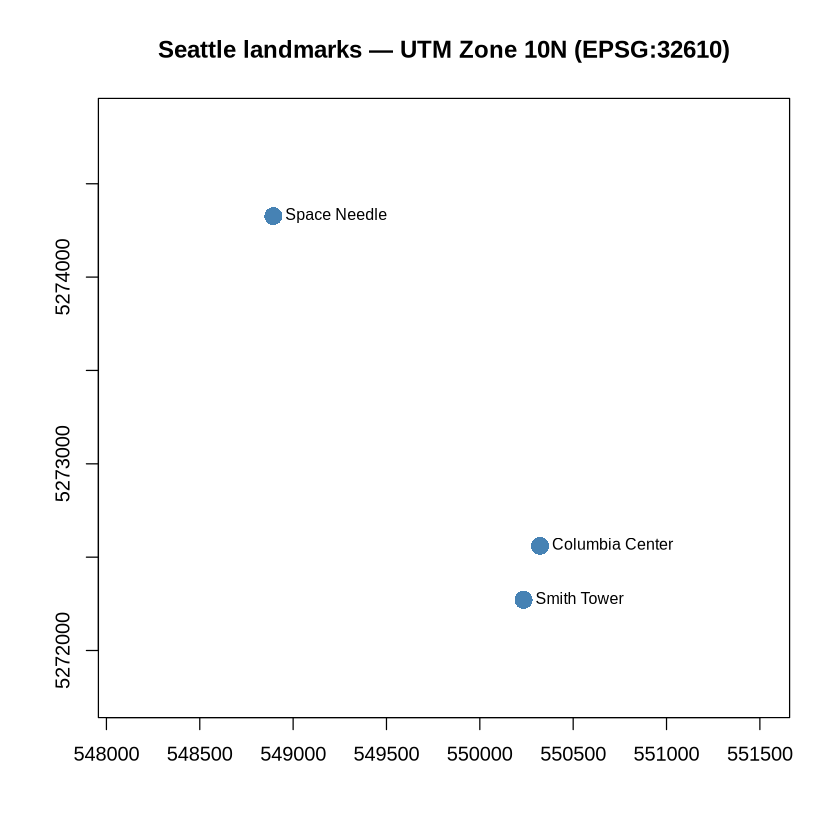

In [5]:
library(sf)

# 1. Three landmarks (longitude, latitude)
landmarks <- st_sf(
  name     = c("Space Needle", "Smith Tower", "Columbia Center"),
  year     = c(1962,           1914,          1985),
  height_m = c(184,            149,           284),
  geometry = st_sfc(
    st_point(c(-122.3493, 47.6205)),
    st_point(c(-122.3317, 47.6019)),
    st_point(c(-122.3305, 47.6045)),
    crs = 4326
  )
)
print(landmarks)

# 2. Project to UTM Zone 10N so the units are meters
landmarks_utm <- st_transform(landmarks, 32610)
st_coordinates(landmarks_utm)

# 3. Distance from each landmark to the Space Needle
landmarks_utm$dist_to_needle_m <- round(
  as.numeric(st_distance(landmarks_utm, landmarks_utm[1, ])), 0
)
st_drop_geometry(landmarks_utm)[, c("name", "dist_to_needle_m")]

# Bonus: distances between every pair of landmarks
dist_matrix <- round(st_distance(landmarks_utm), 0)
dimnames(dist_matrix) <- list(landmarks_utm$name, landmarks_utm$name)
dist_matrix

# 4. Plot and label all three points
xy <- st_coordinates(landmarks_utm)
bb <- st_bbox(landmarks_utm)

plot(st_geometry(landmarks_utm),
     pch = 16, col = "steelblue", cex = 2,
     main = "Seattle landmarks — UTM Zone 10N (EPSG:32610)",
     axes = TRUE,
     xlim = c(bb["xmin"] - 800, bb["xmax"] + 1200),   # room for labels
     ylim = c(bb["ymin"] - 300, bb["ymax"] + 300))
text(xy[, "X"], xy[, "Y"], labels = landmarks_utm$name, pos = 4, cex = 0.8)

Simple feature collection with 4 features and 3 fields
Geometry type: POINT
Dimension:     XY
Bounding box:  xmin: -122.9 ymin: 47 xmax: -117.53 ymax: 48.79
Geodetic CRS:  WGS 84
        name elev_m ann_precip_cm              geometry
1    Sea-Tac    133            96 POINT (-122.31 47.44)
2    Olympia     61           124     POINT (-122.9 47)
3 Bellingham     45            95 POINT (-122.54 48.79)
4    Spokane    720            43 POINT (-117.53 47.62)


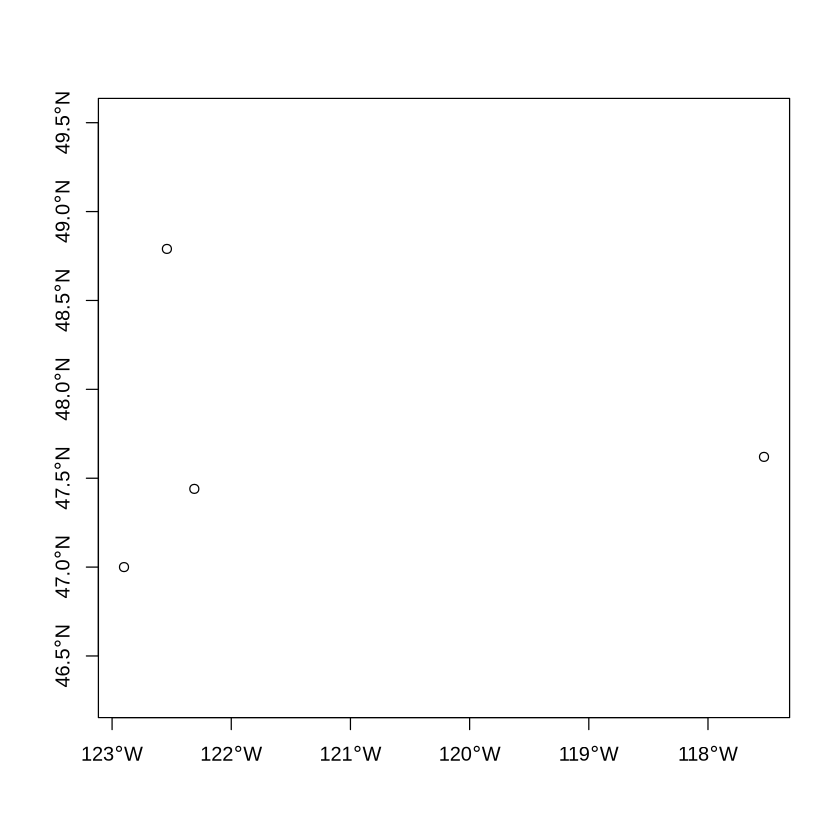

In [7]:
stations <- data.frame(
  name    = c("Sea-Tac", "Olympia", "Bellingham", "Spokane"),
  lat     = c(47.44,     47.00,      48.79,        47.62),
  lon     = c(-122.31,  -122.90,    -122.54,      -117.53),
  elev_m  = c(133,       61,         45,            720),
  ann_precip_cm = c(96,  124,         95,            43)
)

library(sf)

stations_sf <- st_as_sf(stations, coords = c("lon", "lat"), crs = 4326)
print(stations_sf)
plot(stations_sf$geometry, axes = TRUE)

---
## Section 10 — Documenting Your Work: Markdown + Code

This notebook **is** the demonstration — you're already working in a Jupyter notebook that mixes:
- **Markdown cells** (like this one) for narrative, context, and interpretation
- **Code cells** for executable analysis

In R, you can do the same thing with **R Markdown** (`.Rmd` files) or **Quarto** (`.qmd` files).

### Why this matters for GIS work
- Share analysis with teammates who can re-run it
- Document decisions alongside the code that implements them
- Export to HTML or PDF for reports
- Build a portfolio of reproducible spatial analyses

### Basic Markdown syntax

```markdown
# Heading 1
## Heading 2

**bold**, *italic*, `inline code`

- Bullet point
- Another

| Col A | Col B |
|-------|-------|
| val 1 | val 2 |
```

Double-click any Markdown cell in this notebook to see its source.

In [ ]:
# [Python] Example: a mini-analysis with narration in surrounding Markdown cells
import pandas as pd

stations = pd.DataFrame({
    "name":          ["Sea-Tac", "Olympia", "Bellingham", "Spokane"],
    "ann_precip_cm": [96, 124, 95, 43]
})

# Sort by precipitation descending
stations_sorted = stations.sort_values("ann_precip_cm", ascending=False)
print(stations_sorted)

# Quick bar chart
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(6, 3))
ax.barh(stations_sorted["name"], stations_sorted["ann_precip_cm"],
        color="steelblue")
ax.set_xlabel("Annual precipitation (cm)")
ax.set_title("Washington Weather Stations")
plt.tight_layout()
plt.show()

### 🔧 Try it yourself — Documentation
- Double-click this Markdown cell to see its source. Press Shift+Enter to render it again.
- Add a new Markdown cell above the Section 0 code cells that explains what the problem is in your own words.
- Add a Markdown cell below one of the code cells interpreting the output — what does the result mean for the hypothetical planning scenario?

---
## ✅ Module 1 Homework — Completed Notebook

This notebook is your homework deliverable. Complete it with all cells run and output visible in both R and Python sections.

### What to complete

**In-class sections (already done in session):**
- Section 1 — Motivating problem: both R and Python cells run with output visible
- Sections 2–4 — Variables, Strings, Lists: code cells run; at least one "Try it yourself" modified per section

**On your own (complete after class):**
- Sections 5–10 — all code cells run with output visible
- At least one "Try it yourself" prompt attempted per section
- Section 9 spatial teaser: the `sf` (R) and `geopandas` (Python) cells run with a plot rendered
- Section 10: add at least one Markdown cell of your own — a brief annotation of any code output

### Submission checklist

Before submitting, confirm:
- [ ] All code cells have been run (output appears below each cell)
- [ ] No cells show a red error as the only output
- [ ] At least one "Try it yourself" per section has been modified
- [ ] Section 9 spatial plots are visible
- [ ] You added at least one original Markdown annotation somewhere in the notebook

---

**Ran into an error?** Post in the Ed Discussion forum with:
- A screenshot of the error message
- Which cell you were running
- Which operating system / environment you're using

If you solved an issue, post your solution too — this course works best as a learning community.

Look this is a new cell!